# Evaluación del modelo de factores latentes

En este notebook se evaluará el modelo de recomendación basado en factores latentes.

Para ello, se separarán las valoraciones de cada usuario en conjuntos de entrenamiento y prueba, utilizando el mismo procedimiento empleado en la evaluación del modelo de filtrado colaborativo. De esta forma, los resultados obtenidos por ambos modelos podrán compararse bajo unas condiciones similares.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

## 1. Carga y división de los datos

Se carga el conjunto de valoraciones de MovieLens y se realiza una división por usuario, reservando un 20 % de las valoraciones de cada uno para el conjunto de prueba.

In [2]:
ratings = pd.read_csv("../data/raw/ml-latest-small/ratings.csv")

train_parts = []
test_parts = []

for user_id, valoraciones_usuario in ratings.groupby("userId"):

    train_user, test_user = train_test_split(
        valoraciones_usuario,
        test_size=0.2,
        random_state=42
    )

    train_parts.append(train_user)
    test_parts.append(test_user)

ratings_train = pd.concat(train_parts).reset_index(drop=True)
ratings_test = pd.concat(test_parts).reset_index(drop=True)

print("Valoraciones totales:", len(ratings))
print("Valoraciones de entrenamiento:", len(ratings_train))
print("Valoraciones de prueba:", len(ratings_test))

Valoraciones totales: 100836
Valoraciones de entrenamiento: 80419
Valoraciones de prueba: 20417


## 2. Preparación de los datos para el modelo

Los índices internos de usuarios y películas se construyen utilizando exclusivamente el conjunto de entrenamiento. De esta forma, el modelo solo tendrá acceso durante su aprendizaje a la información disponible en dicho conjunto.

In [3]:
usuarios = sorted(ratings_train["userId"].unique())
peliculas = sorted(ratings_train["movieId"].unique())

user_to_idx = {
    user_id: idx
    for idx, user_id in enumerate(usuarios)
}

movie_to_idx = {
    movie_id: idx
    for idx, movie_id in enumerate(peliculas)
}

n_usuarios = len(usuarios)
n_peliculas = len(peliculas)

ratings_train_modelo = ratings_train.copy()

ratings_train_modelo["user_idx"] = (
    ratings_train_modelo["userId"].map(user_to_idx)
)

ratings_train_modelo["movie_idx"] = (
    ratings_train_modelo["movieId"].map(movie_to_idx)
)

print("Usuarios en entrenamiento:", n_usuarios)
print("Películas en entrenamiento:", n_peliculas)

Usuarios en entrenamiento: 610
Películas en entrenamiento: 8965


## 3. Función de entrenamiento del modelo

Se encapsula el proceso de factorización matricial en una función para facilitar el entrenamiento y la posterior comparación de distintas configuraciones de hiperparámetros.

El modelo aprende los factores latentes de usuarios y películas, así como sus respectivos sesgos, utilizando descenso de gradiente estocástico.

In [14]:
def entrenar_modelo(
    ratings_train_modelo,
    n_usuarios,
    n_peliculas,
    n_factores=20,
    learning_rate=0.01,
    regularizacion=0.02,
    n_epocas=20,
    seed=42,
    ratings_test=None,
    user_to_idx=None,
    movie_to_idx=None
):

    np.random.seed(seed)

    P = np.random.normal(
        scale=0.1,
        size=(n_usuarios, n_factores)
    )

    Q = np.random.normal(
        scale=0.1,
        size=(n_peliculas, n_factores)
    )

    bias_usuarios = np.zeros(n_usuarios)
    bias_peliculas = np.zeros(n_peliculas)

    media_global = ratings_train_modelo["rating"].mean()

    errores_train = []
    errores_test = []

    for epoca in range(n_epocas):

        datos_epoca = ratings_train_modelo.sample(
            frac=1,
            random_state=seed + epoca
        )

        error_cuadratico = 0

        for fila in datos_epoca.itertuples():

            u = fila.user_idx
            i = fila.movie_idx
            rating_real = fila.rating

            prediccion = (
                media_global
                + bias_usuarios[u]
                + bias_peliculas[i]
                + np.dot(P[u], Q[i])
            )

            error = rating_real - prediccion

            error_cuadratico += error ** 2

            P_u_anterior = P[u].copy()

            bias_usuarios[u] += learning_rate * (
                error - regularizacion * bias_usuarios[u]
            )

            bias_peliculas[i] += learning_rate * (
                error - regularizacion * bias_peliculas[i]
            )

            P[u] += learning_rate * (
                error * Q[i] - regularizacion * P[u]
            )

            Q[i] += learning_rate * (
                error * P_u_anterior - regularizacion * Q[i]
            )

        rmse_train = np.sqrt(
            error_cuadratico / len(ratings_train_modelo)
        )

        errores_train.append(rmse_train)

        if ratings_test is not None:

            rmse_test = calcular_rmse_test(
                ratings_test,
                P,
                Q,
                bias_usuarios,
                bias_peliculas,
                media_global,
                user_to_idx,
                movie_to_idx
            )

            errores_test.append(rmse_test)

            print(
                f"Época {epoca + 1}/{n_epocas} - "
                f"Train: {rmse_train:.4f} - "
                f"Test: {rmse_test:.4f}"
            )

        else:

            print(
                f"Época {epoca + 1}/{n_epocas} - "
                f"Train: {rmse_train:.4f}"
            )

    return (
        P,
        Q,
        bias_usuarios,
        bias_peliculas,
        media_global,
        errores_train,
        errores_test
    )

## 4. Entrenamiento inicial

Como punto de partida se utiliza la misma configuración empleada durante el desarrollo inicial del modelo: 20 factores latentes, una tasa de aprendizaje de 0.01, regularización de 0.02 y 20 épocas.

In [15]:
P, Q, bias_usuarios, bias_peliculas, media_global, errores_train, errores_test = entrenar_modelo(
    ratings_train_modelo,
    n_usuarios,
    n_peliculas,
    n_factores=20,
    learning_rate=0.01,
    regularizacion=0.02,
    n_epocas=20,
    ratings_test=ratings_test,
    user_to_idx=user_to_idx,
    movie_to_idx=movie_to_idx
)

Época 1/20 - Train: 0.9435 - Test: 0.9138
Época 2/20 - Train: 0.8899 - Test: 0.8953
Época 3/20 - Train: 0.8696 - Test: 0.8862
Época 4/20 - Train: 0.8557 - Test: 0.8818
Época 5/20 - Train: 0.8449 - Test: 0.8788
Época 6/20 - Train: 0.8351 - Test: 0.8760
Época 7/20 - Train: 0.8256 - Test: 0.8739
Época 8/20 - Train: 0.8157 - Test: 0.8725
Época 9/20 - Train: 0.8052 - Test: 0.8706
Época 10/20 - Train: 0.7934 - Test: 0.8688
Época 11/20 - Train: 0.7805 - Test: 0.8696
Época 12/20 - Train: 0.7661 - Test: 0.8675
Época 13/20 - Train: 0.7504 - Test: 0.8671
Época 14/20 - Train: 0.7338 - Test: 0.8670
Época 15/20 - Train: 0.7166 - Test: 0.8668
Época 16/20 - Train: 0.6995 - Test: 0.8676
Época 17/20 - Train: 0.6822 - Test: 0.8683
Época 18/20 - Train: 0.6654 - Test: 0.8700
Época 19/20 - Train: 0.6494 - Test: 0.8718
Época 20/20 - Train: 0.6341 - Test: 0.8730


## 5. Evaluación sobre el conjunto de prueba

Una vez entrenado el modelo, se realizan predicciones sobre las valoraciones reservadas en el conjunto de prueba.

Solo se evaluarán aquellas valoraciones correspondientes a usuarios y películas presentes durante el entrenamiento, ya que el modelo necesita haber aprendido previamente sus factores latentes.

In [6]:
reales = []
predicciones = []

no_predecibles = 0

for fila in ratings_test.itertuples():

    usuario_id = fila.userId
    pelicula_id = fila.movieId
    rating_real = fila.rating

    if (
        usuario_id not in user_to_idx
        or pelicula_id not in movie_to_idx
    ):
        no_predecibles += 1
        continue

    u = user_to_idx[usuario_id]
    i = movie_to_idx[pelicula_id]

    prediccion = (
        media_global
        + bias_usuarios[u]
        + bias_peliculas[i]
        + np.dot(P[u], Q[i])
    )

    # Para evaluar ratings sí respetamos la escala de MovieLens
    prediccion = np.clip(prediccion, 0.5, 5.0)

    reales.append(rating_real)
    predicciones.append(prediccion)

print("Valoraciones de test:", len(ratings_test))
print("Valoraciones evaluadas:", len(predicciones))
print("Valoraciones no predecibles:", no_predecibles)

Valoraciones de test: 20417
Valoraciones evaluadas: 19590
Valoraciones no predecibles: 827


### Métricas de evaluación

Se utilizan RMSE y MAE para medir la diferencia entre las valoraciones reales del conjunto de prueba y las estimadas por el modelo.

In [8]:
rmse = np.sqrt(
    mean_squared_error(reales, predicciones)
)

mae = mean_absolute_error(
    reales,
    predicciones
)

print(f"RMSE test: {rmse:.4f}")
print(f"MAE test: {mae:.4f}")

RMSE test: 0.8730
MAE test: 0.6680


## 6. Evolución del rendimiento durante el entrenamiento

Para analizar la capacidad de generalización del modelo, se observará la evolución del error sobre entrenamiento y prueba a medida que aumenta el número de épocas.

Esto permitirá comprobar si continuar el entrenamiento mejora las predicciones o provoca sobreajuste.

In [9]:
def calcular_rmse_test(
    ratings_test,
    P,
    Q,
    bias_usuarios,
    bias_peliculas,
    media_global,
    user_to_idx,
    movie_to_idx
):

    reales = []
    predicciones = []

    for fila in ratings_test.itertuples():

        if (
            fila.userId not in user_to_idx
            or fila.movieId not in movie_to_idx
        ):
            continue

        u = user_to_idx[fila.userId]
        i = movie_to_idx[fila.movieId]

        prediccion = (
            media_global
            + bias_usuarios[u]
            + bias_peliculas[i]
            + np.dot(P[u], Q[i])
        )

        prediccion = np.clip(prediccion, 0.5, 5.0)

        reales.append(fila.rating)
        predicciones.append(prediccion)

    return np.sqrt(
        mean_squared_error(reales, predicciones)
    )

### Evolución del RMSE

Se representa la evolución del RMSE sobre los conjuntos de entrenamiento y prueba para analizar el comportamiento del modelo a medida que avanza el aprendizaje y detectar posibles signos de sobreajuste.

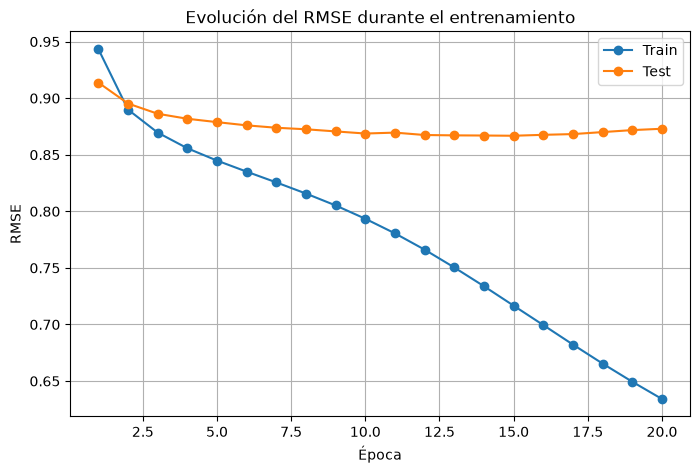

In [17]:
epocas = range(1, len(errores_train) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epocas, errores_train, marker="o", label="Train")
plt.plot(epocas, errores_test, marker="o", label="Test")

plt.xlabel("Época")
plt.ylabel("RMSE")
plt.title("Evolución del RMSE durante el entrenamiento")
plt.legend()
plt.grid()

plt.show()

## 7. Comparación del número de factores latentes

El número de factores latentes determina la dimensión de las representaciones aprendidas para usuarios y películas.

Se probarán diferentes valores para analizar cómo afecta la complejidad del modelo a su capacidad de generalización. Para cada configuración se utilizará el mejor RMSE obtenido sobre el conjunto de prueba durante el entrenamiento.

In [18]:
factores_a_probar = [10, 20, 50]

resultados_factores = []

for n_factores in factores_a_probar:

    print(f"\nEntrenando modelo con {n_factores} factores...")

    (
        P_temp,
        Q_temp,
        bias_usuarios_temp,
        bias_peliculas_temp,
        media_global_temp,
        errores_train_temp,
        errores_test_temp
    ) = entrenar_modelo(
        ratings_train_modelo,
        n_usuarios,
        n_peliculas,
        n_factores=n_factores,
        learning_rate=0.01,
        regularizacion=0.02,
        n_epocas=20,
        ratings_test=ratings_test,
        user_to_idx=user_to_idx,
        movie_to_idx=movie_to_idx
    )

    mejor_rmse = min(errores_test_temp)
    mejor_epoca = np.argmin(errores_test_temp) + 1

    resultados_factores.append({
        "factores": n_factores,
        "mejor_rmse_test": mejor_rmse,
        "mejor_epoca": mejor_epoca
    })


Entrenando modelo con 10 factores...
Época 1/20 - Train: 0.9433 - Test: 0.9136
Época 2/20 - Train: 0.8913 - Test: 0.8951
Época 3/20 - Train: 0.8723 - Test: 0.8861
Época 4/20 - Train: 0.8599 - Test: 0.8818
Época 5/20 - Train: 0.8506 - Test: 0.8789
Época 6/20 - Train: 0.8427 - Test: 0.8763
Época 7/20 - Train: 0.8355 - Test: 0.8742
Época 8/20 - Train: 0.8285 - Test: 0.8732
Época 9/20 - Train: 0.8214 - Test: 0.8715
Época 10/20 - Train: 0.8138 - Test: 0.8700
Época 11/20 - Train: 0.8055 - Test: 0.8710
Época 12/20 - Train: 0.7965 - Test: 0.8689
Época 13/20 - Train: 0.7862 - Test: 0.8684
Época 14/20 - Train: 0.7753 - Test: 0.8684
Época 15/20 - Train: 0.7637 - Test: 0.8679
Época 16/20 - Train: 0.7519 - Test: 0.8684
Época 17/20 - Train: 0.7395 - Test: 0.8687
Época 18/20 - Train: 0.7274 - Test: 0.8703
Época 19/20 - Train: 0.7156 - Test: 0.8719
Época 20/20 - Train: 0.7043 - Test: 0.8724

Entrenando modelo con 20 factores...
Época 1/20 - Train: 0.9435 - Test: 0.9138
Época 2/20 - Train: 0.8899 - Te

In [19]:
resultados_factores_df = pd.DataFrame(resultados_factores)

resultados_factores_df

,factores,mejor_rmse_test,mejor_epoca
0,10,0.867871,15
1,20,0.866801,15
2,50,0.870030,12


## 8. Ajuste de la regularización

La regularización controla el crecimiento de los parámetros aprendidos por el modelo y permite reducir el riesgo de sobreajuste.

Manteniendo 20 factores latentes, se comparan distintos valores de regularización para analizar su efecto sobre el rendimiento del modelo.

In [20]:
regularizaciones = [0.01, 0.02, 0.05, 0.1]

resultados_regularizacion = []

for reg in regularizaciones:

    print(f"\nRegularización = {reg}")

    (
        P_temp,
        Q_temp,
        bias_usuarios_temp,
        bias_peliculas_temp,
        media_global_temp,
        errores_train_temp,
        errores_test_temp
    ) = entrenar_modelo(
        ratings_train_modelo,
        n_usuarios,
        n_peliculas,
        n_factores=20,
        learning_rate=0.01,
        regularizacion=reg,
        n_epocas=20,
        ratings_test=ratings_test,
        user_to_idx=user_to_idx,
        movie_to_idx=movie_to_idx
    )

    mejor_rmse = min(errores_test_temp)
    mejor_epoca = np.argmin(errores_test_temp) + 1

    resultados_regularizacion.append({
        "regularizacion": reg,
        "mejor_rmse_test": mejor_rmse,
        "mejor_epoca": mejor_epoca
    })


Regularización = 0.01
Época 1/20 - Train: 0.9434 - Test: 0.9138
Época 2/20 - Train: 0.8897 - Test: 0.8953
Época 3/20 - Train: 0.8690 - Test: 0.8863
Época 4/20 - Train: 0.8547 - Test: 0.8820
Época 5/20 - Train: 0.8430 - Test: 0.8790
Época 6/20 - Train: 0.8321 - Test: 0.8762
Época 7/20 - Train: 0.8209 - Test: 0.8742
Época 8/20 - Train: 0.8088 - Test: 0.8730
Época 9/20 - Train: 0.7954 - Test: 0.8714
Época 10/20 - Train: 0.7801 - Test: 0.8699
Época 11/20 - Train: 0.7632 - Test: 0.8714
Época 12/20 - Train: 0.7447 - Test: 0.8704
Época 13/20 - Train: 0.7252 - Test: 0.8713
Época 14/20 - Train: 0.7053 - Test: 0.8726
Época 15/20 - Train: 0.6855 - Test: 0.8740
Época 16/20 - Train: 0.6664 - Test: 0.8763
Época 17/20 - Train: 0.6478 - Test: 0.8785
Época 18/20 - Train: 0.6303 - Test: 0.8816
Época 19/20 - Train: 0.6139 - Test: 0.8847
Época 20/20 - Train: 0.5986 - Test: 0.8872

Regularización = 0.02
Época 1/20 - Train: 0.9435 - Test: 0.9138
Época 2/20 - Train: 0.8899 - Test: 0.8953
Época 3/20 - Train:

In [21]:
resultados_regularizacion_df = pd.DataFrame(
    resultados_regularizacion
)

resultados_regularizacion_df

,regularizacion,mejor_rmse_test,mejor_epoca
0,0.01,0.869927,10
1,0.02,0.866801,15
2,0.05,0.860897,20
3,0.10,0.865113,20


### Ampliación del entrenamiento con la mejor regularización

Dado que la configuración con regularización 0.05 alcanza su mejor resultado en la última época evaluada, se amplía el número de épocas para comprobar si el modelo continúa mejorando antes de comenzar a sobreajustar.

In [22]:
(
    P_temp,
    Q_temp,
    bias_usuarios_temp,
    bias_peliculas_temp,
    media_global_temp,
    errores_train_temp,
    errores_test_temp
) = entrenar_modelo(
    ratings_train_modelo,
    n_usuarios,
    n_peliculas,
    n_factores=20,
    learning_rate=0.01,
    regularizacion=0.05,
    n_epocas=40,
    ratings_test=ratings_test,
    user_to_idx=user_to_idx,
    movie_to_idx=movie_to_idx
)

mejor_rmse = min(errores_test_temp)
mejor_epoca = np.argmin(errores_test_temp) + 1

print(f"Mejor RMSE test: {mejor_rmse:.4f}")
print(f"Mejor época: {mejor_epoca}")

Época 1/40 - Train: 0.9438 - Test: 0.9140
Época 2/40 - Train: 0.8907 - Test: 0.8955
Época 3/40 - Train: 0.8711 - Test: 0.8863
Época 4/40 - Train: 0.8583 - Test: 0.8819
Época 5/40 - Train: 0.8487 - Test: 0.8789
Época 6/40 - Train: 0.8408 - Test: 0.8761
Época 7/40 - Train: 0.8337 - Test: 0.8739
Época 8/40 - Train: 0.8270 - Test: 0.8727
Época 9/40 - Train: 0.8206 - Test: 0.8708
Época 10/40 - Train: 0.8140 - Test: 0.8690
Época 11/40 - Train: 0.8074 - Test: 0.8698
Época 12/40 - Train: 0.8003 - Test: 0.8674
Época 13/40 - Train: 0.7925 - Test: 0.8665
Época 14/40 - Train: 0.7843 - Test: 0.8656
Época 15/40 - Train: 0.7753 - Test: 0.8643
Época 16/40 - Train: 0.7660 - Test: 0.8636
Época 17/40 - Train: 0.7558 - Test: 0.8624
Época 18/40 - Train: 0.7450 - Test: 0.8625
Época 19/40 - Train: 0.7340 - Test: 0.8622
Época 20/40 - Train: 0.7228 - Test: 0.8609
Época 21/40 - Train: 0.7114 - Test: 0.8602
Época 22/40 - Train: 0.7003 - Test: 0.8603
Época 23/40 - Train: 0.6891 - Test: 0.8606
Época 24/40 - Train:

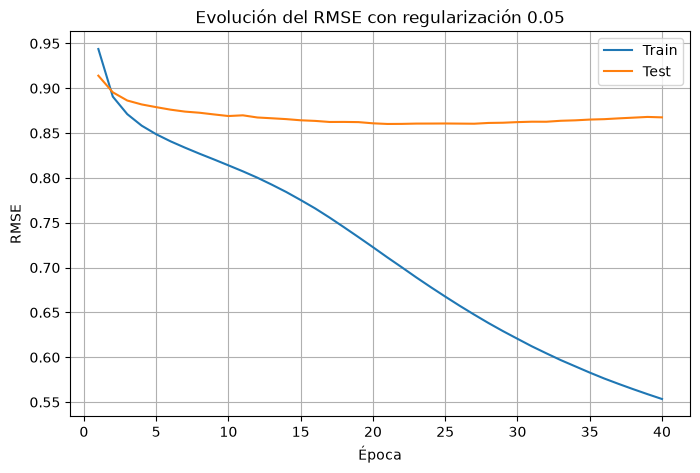

In [23]:
epocas = range(1, len(errores_test_temp) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epocas, errores_train_temp, label="Train")
plt.plot(epocas, errores_test_temp, label="Test")

plt.xlabel("Época")
plt.ylabel("RMSE")
plt.title("Evolución del RMSE con regularización 0.05")
plt.legend()
plt.grid()

plt.show()

## 9. Ajuste de la tasa de aprendizaje

La tasa de aprendizaje determina el tamaño de las actualizaciones realizadas durante el descenso de gradiente.

Se prueban diferentes valores manteniendo el número de factores y la regularización seleccionados anteriormente, con el objetivo de encontrar una velocidad de aprendizaje que permita mejorar la capacidad de generalización del modelo.

In [24]:
learning_rates = [0.0025, 0.005, 0.01, 0.02]

resultados_lr = []

for lr in learning_rates:

    print(f"\nLearning rate = {lr}")

    (
        P_temp,
        Q_temp,
        bias_usuarios_temp,
        bias_peliculas_temp,
        media_global_temp,
        errores_train_temp,
        errores_test_temp
    ) = entrenar_modelo(
        ratings_train_modelo,
        n_usuarios,
        n_peliculas,
        n_factores=20,
        learning_rate=lr,
        regularizacion=0.05,
        n_epocas=40,
        ratings_test=ratings_test,
        user_to_idx=user_to_idx,
        movie_to_idx=movie_to_idx
    )

    mejor_rmse = min(errores_test_temp)
    mejor_epoca = np.argmin(errores_test_temp) + 1

    resultados_lr.append({
        "learning_rate": lr,
        "mejor_rmse_test": mejor_rmse,
        "mejor_epoca": mejor_epoca
    })


Learning rate = 0.0025
Época 1/40 - Train: 0.9857 - Test: 0.9611
Época 2/40 - Train: 0.9385 - Test: 0.9359
Época 3/40 - Train: 0.9175 - Test: 0.9224
Época 4/40 - Train: 0.9042 - Test: 0.9136
Época 5/40 - Train: 0.8946 - Test: 0.9074
Época 6/40 - Train: 0.8871 - Test: 0.9027
Época 7/40 - Train: 0.8808 - Test: 0.8987
Época 8/40 - Train: 0.8755 - Test: 0.8956
Época 9/40 - Train: 0.8709 - Test: 0.8928
Época 10/40 - Train: 0.8667 - Test: 0.8902
Época 11/40 - Train: 0.8630 - Test: 0.8886
Época 12/40 - Train: 0.8597 - Test: 0.8865
Época 13/40 - Train: 0.8565 - Test: 0.8849
Época 14/40 - Train: 0.8536 - Test: 0.8834
Época 15/40 - Train: 0.8509 - Test: 0.8821
Época 16/40 - Train: 0.8484 - Test: 0.8810
Época 17/40 - Train: 0.8460 - Test: 0.8798
Época 18/40 - Train: 0.8437 - Test: 0.8791
Época 19/40 - Train: 0.8415 - Test: 0.8786
Época 20/40 - Train: 0.8394 - Test: 0.8774
Época 21/40 - Train: 0.8374 - Test: 0.8765
Época 22/40 - Train: 0.8355 - Test: 0.8761
Época 23/40 - Train: 0.8336 - Test: 0.8

In [25]:
resultados_lr_df = pd.DataFrame(resultados_lr)

resultados_lr_df

,learning_rate,mejor_rmse_test,mejor_epoca
0,0.0025,0.868808,40
1,0.0050,0.860533,40
2,0.0100,0.860176,21
3,0.0200,0.860862,12


## 10. Comparación con un modelo baseline

Para contextualizar el rendimiento obtenido por el modelo de factores latentes, se establece un modelo de referencia sencillo.

Este baseline predice para todas las valoraciones del conjunto de prueba la media global calculada exclusivamente a partir de las valoraciones de entrenamiento. Su resultado permite comprobar si el modelo desarrollado aporta una mejora real respecto a una estrategia de predicción básica.

In [26]:
media_baseline = ratings_train["rating"].mean()

predicciones_baseline = np.full(
    len(ratings_test),
    media_baseline
)

rmse_baseline = np.sqrt(
    mean_squared_error(
        ratings_test["rating"],
        predicciones_baseline
    )
)

mae_baseline = mean_absolute_error(
    ratings_test["rating"],
    predicciones_baseline
)

print(f"Media global: {media_baseline:.4f}")
print(f"RMSE baseline: {rmse_baseline:.4f}")
print(f"MAE baseline: {mae_baseline:.4f}")

Media global: 3.5029
RMSE baseline: 1.0500
MAE baseline: 0.8331


### Comparación sobre las mismas valoraciones

Para garantizar una comparación homogénea, se calcula también el rendimiento del baseline únicamente sobre aquellas valoraciones del conjunto de prueba que pueden ser predichas por el modelo de factores latentes.

In [27]:
test_predecible = ratings_test[
    ratings_test["userId"].isin(user_to_idx) &
    ratings_test["movieId"].isin(movie_to_idx)
].copy()

predicciones_baseline_comparable = np.full(
    len(test_predecible),
    media_baseline
)

rmse_baseline_comparable = np.sqrt(
    mean_squared_error(
        test_predecible["rating"],
        predicciones_baseline_comparable
    )
)

mae_baseline_comparable = mean_absolute_error(
    test_predecible["rating"],
    predicciones_baseline_comparable
)

print("Valoraciones comparadas:", len(test_predecible))
print(f"RMSE baseline comparable: {rmse_baseline_comparable:.4f}")
print(f"MAE baseline comparable: {mae_baseline_comparable:.4f}")

Valoraciones comparadas: 19590
RMSE baseline comparable: 1.0453
MAE baseline comparable: 0.8305


## 11. Entrenamiento del mejor modelo provisional

A partir de los experimentos realizados, se selecciona provisionalmente la configuración que ha obtenido el menor RMSE: 20 factores latentes, tasa de aprendizaje 0.01, regularización 0.05 y 21 épocas.

El modelo se entrena nuevamente con esta configuración para calcular sus métricas finales de predicción y compararlas con el baseline.

In [28]:
(
    P_mejor,
    Q_mejor,
    bias_usuarios_mejor,
    bias_peliculas_mejor,
    media_global_mejor,
    errores_train_mejor,
    errores_test_mejor
) = entrenar_modelo(
    ratings_train_modelo,
    n_usuarios,
    n_peliculas,
    n_factores=20,
    learning_rate=0.01,
    regularizacion=0.05,
    n_epocas=21,
    ratings_test=ratings_test,
    user_to_idx=user_to_idx,
    movie_to_idx=movie_to_idx
)

Época 1/21 - Train: 0.9438 - Test: 0.9140
Época 2/21 - Train: 0.8907 - Test: 0.8955
Época 3/21 - Train: 0.8711 - Test: 0.8863
Época 4/21 - Train: 0.8583 - Test: 0.8819
Época 5/21 - Train: 0.8487 - Test: 0.8789
Época 6/21 - Train: 0.8408 - Test: 0.8761
Época 7/21 - Train: 0.8337 - Test: 0.8739
Época 8/21 - Train: 0.8270 - Test: 0.8727
Época 9/21 - Train: 0.8206 - Test: 0.8708
Época 10/21 - Train: 0.8140 - Test: 0.8690
Época 11/21 - Train: 0.8074 - Test: 0.8698
Época 12/21 - Train: 0.8003 - Test: 0.8674
Época 13/21 - Train: 0.7925 - Test: 0.8665
Época 14/21 - Train: 0.7843 - Test: 0.8656
Época 15/21 - Train: 0.7753 - Test: 0.8643
Época 16/21 - Train: 0.7660 - Test: 0.8636
Época 17/21 - Train: 0.7558 - Test: 0.8624
Época 18/21 - Train: 0.7450 - Test: 0.8625
Época 19/21 - Train: 0.7340 - Test: 0.8622
Época 20/21 - Train: 0.7228 - Test: 0.8609
Época 21/21 - Train: 0.7114 - Test: 0.8602


In [29]:
reales_mejor = []
predicciones_mejor = []

for fila in test_predecible.itertuples():

    u = user_to_idx[fila.userId]
    i = movie_to_idx[fila.movieId]

    prediccion = (
        media_global_mejor
        + bias_usuarios_mejor[u]
        + bias_peliculas_mejor[i]
        + np.dot(P_mejor[u], Q_mejor[i])
    )

    prediccion = np.clip(prediccion, 0.5, 5.0)

    reales_mejor.append(fila.rating)
    predicciones_mejor.append(prediccion)

rmse_mejor = np.sqrt(
    mean_squared_error(reales_mejor, predicciones_mejor)
)

mae_mejor = mean_absolute_error(
    reales_mejor,
    predicciones_mejor
)

print(f"RMSE factores latentes: {rmse_mejor:.4f}")
print(f"MAE factores latentes: {mae_mejor:.4f}")

RMSE factores latentes: 0.8602
MAE factores latentes: 0.6587


## 12. Evaluación de las recomendaciones Top-N

Además de evaluar la capacidad del modelo para predecir valoraciones mediante RMSE y MAE, resulta necesario analizar la calidad de las recomendaciones generadas.

Para ello se utilizarán métricas orientadas al ranking, considerando como películas relevantes aquellas que el usuario ha valorado con una puntuación igual o superior a 4 en el conjunto de prueba.

Se utilizarán Precision@K y Recall@K para comprobar cuántas películas relevantes aparecen entre las primeras recomendaciones realizadas por el modelo.

In [30]:
def recomendar_top_n(
    usuario_id,
    n=10
):

    if usuario_id not in user_to_idx:
        return []

    u = user_to_idx[usuario_id]

    vistas_train = set(
        ratings_train.loc[
            ratings_train["userId"] == usuario_id,
            "movieId"
        ]
    )

    predicciones = []

    for pelicula_id in peliculas:

        if pelicula_id in vistas_train:
            continue

        i = movie_to_idx[pelicula_id]

        prediccion = (
            media_global_mejor
            + bias_usuarios_mejor[u]
            + bias_peliculas_mejor[i]
            + np.dot(P_mejor[u], Q_mejor[i])
        )

        predicciones.append(
            (pelicula_id, prediccion)
        )

    predicciones.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return predicciones[:n]

### Precision@K y Recall@K

Precision@K mide qué proporción de las primeras K recomendaciones realizadas por el modelo corresponde a películas relevantes para el usuario.

Recall@K mide qué proporción de las películas relevantes disponibles en el conjunto de prueba ha sido recuperada entre esas K recomendaciones.

In [33]:
def evaluar_top_n(k=10, umbral_relevante=4.0):

    precisiones = []
    recalls = []

    for usuario_id in usuarios:

        relevantes = set(
            ratings_test.loc[
                (ratings_test["userId"] == usuario_id) &
                (ratings_test["rating"] >= umbral_relevante) &
                (ratings_test["movieId"].isin(movie_to_idx)),
                "movieId"
            ]
        )

        # Si el usuario no tiene películas relevantes en test,
        # no podemos calcular recall de forma útil
        if len(relevantes) == 0:
            continue

        recomendaciones = recomendar_top_n(
            usuario_id,
            n=k
        )

        recomendadas = {
            pelicula_id
            for pelicula_id, _ in recomendaciones
        }

        aciertos = len(
            recomendadas.intersection(relevantes)
        )

        precision = aciertos / k
        recall = aciertos / len(relevantes)

        precisiones.append(precision)
        recalls.append(recall)

    return (
        np.mean(precisiones),
        np.mean(recalls),
        len(precisiones)
    )

In [32]:
precision_10, recall_10, usuarios_evaluados = evaluar_top_n(
    k=10,
    umbral_relevante=4.0
)

print("Usuarios evaluados:", usuarios_evaluados)
print(f"Precision@10: {precision_10:.4f}")
print(f"Recall@10: {recall_10:.4f}")

Usuarios evaluados: 600
Precision@10: 0.0280
Recall@10: 0.0205


## 13. Comparación con un recomendador basado en popularidad

Como referencia para la evaluación Top-N, se construye un recomendador sencillo basado en la popularidad de las películas.

Las películas se ordenan según el número de valoraciones recibidas en el conjunto de entrenamiento. Para cada usuario se excluyen las películas que ya ha valorado y se seleccionan las primeras K películas restantes.

Este enfoque permite comprobar si el modelo de factores latentes aporta valor frente a una estrategia no personalizada.

In [34]:
popularidad = (
    ratings_train
    .groupby("movieId")
    .size()
    .sort_values(ascending=False)
)

peliculas_populares = popularidad.index.tolist()

In [35]:
def recomendar_popularidad(usuario_id, n=10):

    vistas_train = set(
        ratings_train.loc[
            ratings_train["userId"] == usuario_id,
            "movieId"
        ]
    )

    recomendaciones = [
        pelicula_id
        for pelicula_id in peliculas_populares
        if pelicula_id not in vistas_train
    ]

    return recomendaciones[:n]

### Evaluación del baseline de popularidad

Se calculan Precision@10 y Recall@10 utilizando el mismo criterio de relevancia empleado para el modelo de factores latentes, considerando relevantes las películas con una valoración igual o superior a 4.

In [42]:
def evaluar_popularidad(k=10, umbral_relevante=4.0):

    precisiones = []
    recalls = []

    for usuario_id in usuarios:

        relevantes = set(
            ratings_test.loc[
                (ratings_test["userId"] == usuario_id) &
                (ratings_test["rating"] >= umbral_relevante) &
                (ratings_test["movieId"].isin(movie_to_idx)),
                "movieId"
            ]
        )

        if len(relevantes) == 0:
            continue

        recomendadas = set(
            recomendar_popularidad(
                usuario_id,
                n=k
            )
        )

        aciertos = len(
            recomendadas.intersection(relevantes)
        )

        precision = aciertos / k
        recall = aciertos / len(relevantes)

        precisiones.append(precision)
        recalls.append(recall)

    return (
        np.mean(precisiones),
        np.mean(recalls),
        len(precisiones)
    )

In [43]:
precision_pop, recall_pop, usuarios_pop = evaluar_popularidad(
    k=10,
    umbral_relevante=4.0
)

print("Usuarios evaluados:", usuarios_pop)
print(f"Precision@10 popularidad: {precision_pop:.4f}")
print(f"Recall@10 popularidad: {recall_pop:.4f}")

Usuarios evaluados: 600
Precision@10 popularidad: 0.1233
Recall@10 popularidad: 0.1004


## 14. Evaluación Top-N mediante muestreo de candidatos

La evaluación realizada sobre el catálogo completo supone seleccionar las películas relevantes entre varios miles de candidatos, en un conjunto de datos caracterizado por una elevada dispersión.

Como evaluación complementaria, se construye para cada usuario un conjunto de candidatos formado por sus películas relevantes del conjunto de prueba y una muestra aleatoria de películas no observadas.

Posteriormente, los candidatos se ordenan según la puntuación predicha por el modelo y se calculan nuevamente Precision@10 y Recall@10.

In [40]:
def evaluar_top_n_muestreo(
    k=10,
    umbral_relevante=4.0,
    n_negativos=100,
    semilla=42
):

    rng = np.random.default_rng(semilla)

    precisiones = []
    recalls = []

    todas_peliculas = set(movie_to_idx.keys())

    for usuario_id in usuarios:

        relevantes = set(
            ratings_test.loc[
                (ratings_test["userId"] == usuario_id) &
                (ratings_test["rating"] >= umbral_relevante) &
                (ratings_test["movieId"].isin(movie_to_idx)),
                "movieId"
            ]
        )

        if len(relevantes) == 0:
            continue

        vistas = set(
            ratings.loc[
                ratings["userId"] == usuario_id,
                "movieId"
            ]
        )

        negativas_posibles = list(
            todas_peliculas - vistas
        )

        n_muestra = min(
            n_negativos,
            len(negativas_posibles)
        )

        negativas = set(
            rng.choice(
                negativas_posibles,
                size=n_muestra,
                replace=False
            )
        )

        candidatos = relevantes | negativas

        u = user_to_idx[usuario_id]

        puntuaciones = []

        for pelicula_id in candidatos:

            i = movie_to_idx[pelicula_id]

            prediccion = (
                media_global_mejor
                + bias_usuarios_mejor[u]
                + bias_peliculas_mejor[i]
                + np.dot(P_mejor[u], Q_mejor[i])
            )

            puntuaciones.append(
                (pelicula_id, prediccion)
            )

        puntuaciones.sort(
            key=lambda x: x[1],
            reverse=True
        )

        recomendadas = {
            pelicula_id
            for pelicula_id, _ in puntuaciones[:k]
        }

        aciertos = len(
            recomendadas.intersection(relevantes)
        )

        precisiones.append(
            aciertos / k
        )

        recalls.append(
            aciertos / len(relevantes)
        )

    return (
        np.mean(precisiones),
        np.mean(recalls),
        len(precisiones)
    )

In [41]:
precision_muestreo, recall_muestreo, usuarios_muestreo = (
    evaluar_top_n_muestreo(
        k=10,
        umbral_relevante=4.0,
        n_negativos=100,
        semilla=42
    )
)

print("Usuarios evaluados:", usuarios_muestreo)
print(f"Precision@10: {precision_muestreo:.4f}")
print(f"Recall@10: {recall_muestreo:.4f}")

Usuarios evaluados: 600
Precision@10: 0.3805
Recall@10: 0.3454


## 15. Comparación Top-N sobre el mismo conjunto de candidatos

Para realizar una comparación homogénea entre el modelo de factores latentes y el recomendador basado en popularidad, ambos métodos se evalúan utilizando exactamente el mismo conjunto de películas candidatas para cada usuario.

El conjunto está formado por las películas relevantes del usuario presentes en prueba y una muestra de 100 películas no observadas. Posteriormente, cada modelo ordena de forma independiente los mismos candidatos y se calculan Precision@10 y Recall@10.

In [44]:
popularidad_dict = popularidad.to_dict()

In [45]:
def comparar_top_n_muestreo(
    k=10,
    umbral_relevante=4.0,
    n_negativos=100,
    semilla=42
):

    rng = np.random.default_rng(semilla)

    precision_mf = []
    recall_mf = []

    precision_pop = []
    recall_pop = []

    todas_peliculas = set(movie_to_idx.keys())

    for usuario_id in usuarios:

        # Películas relevantes del usuario en test
        relevantes = set(
            ratings_test.loc[
                (ratings_test["userId"] == usuario_id) &
                (ratings_test["rating"] >= umbral_relevante) &
                (ratings_test["movieId"].isin(movie_to_idx)),
                "movieId"
            ]
        )

        if len(relevantes) == 0:
            continue

        # Películas que el usuario ha valorado
        vistas = set(
            ratings.loc[
                ratings["userId"] == usuario_id,
                "movieId"
            ]
        )

        # Posibles negativos
        negativas_posibles = list(
            todas_peliculas - vistas
        )

        n_muestra = min(
            n_negativos,
            len(negativas_posibles)
        )

        negativas = set(
            rng.choice(
                negativas_posibles,
                size=n_muestra,
                replace=False
            )
        )

        # EXACTAMENTE los mismos candidatos para ambos modelos
        candidatos = relevantes | negativas

        # -------------------------
        # Factores latentes
        # -------------------------

        u = user_to_idx[usuario_id]

        scores_mf = []

        for pelicula_id in candidatos:

            i = movie_to_idx[pelicula_id]

            prediccion = (
                media_global_mejor
                + bias_usuarios_mejor[u]
                + bias_peliculas_mejor[i]
                + np.dot(P_mejor[u], Q_mejor[i])
            )

            scores_mf.append(
                (pelicula_id, prediccion)
            )

        scores_mf.sort(
            key=lambda x: x[1],
            reverse=True
        )

        recomendadas_mf = {
            pelicula_id
            for pelicula_id, _ in scores_mf[:k]
        }

        # -------------------------
        # Popularidad
        # -------------------------

        scores_pop = [
            (
                pelicula_id,
                popularidad_dict.get(pelicula_id, 0)
            )
            for pelicula_id in candidatos
        ]

        scores_pop.sort(
            key=lambda x: x[1],
            reverse=True
        )

        recomendadas_pop = {
            pelicula_id
            for pelicula_id, _ in scores_pop[:k]
        }

        # -------------------------
        # Métricas
        # -------------------------

        aciertos_mf = len(
            recomendadas_mf.intersection(relevantes)
        )

        aciertos_pop = len(
            recomendadas_pop.intersection(relevantes)
        )

        precision_mf.append(
            aciertos_mf / k
        )

        recall_mf.append(
            aciertos_mf / len(relevantes)
        )

        precision_pop.append(
            aciertos_pop / k
        )

        recall_pop.append(
            aciertos_pop / len(relevantes)
        )

    return {
        "MF Precision@10": np.mean(precision_mf),
        "MF Recall@10": np.mean(recall_mf),
        "Popularidad Precision@10": np.mean(precision_pop),
        "Popularidad Recall@10": np.mean(recall_pop),
        "Usuarios evaluados": len(precision_mf)
    }

In [46]:
comparacion_muestreo = comparar_top_n_muestreo(
    k=10,
    umbral_relevante=4.0,
    n_negativos=100,
    semilla=42
)

comparacion_muestreo

{'MF Precision@10': np.float64(0.3805),
 'MF Recall@10': np.float64(0.3454332728565534),
 'Popularidad Precision@10': np.float64(0.5498333333333333),
 'Popularidad Recall@10': np.float64(0.5663593422968227),
 'Usuarios evaluados': 600}